# AirplaneServices: Machine Learning from Disaster
Goal: Predict of passenger satisfaction.

Steps:
- Defining the problem statement
- Collecting the data
- Exploratory data analysis
- Data Preprocessing (Feature engineering)
- Modeling
- Evaluation

# Defining the Problem Statement
Complete the analysis of what is a classification. In particular, I apply the tools of machine learning to predict one of two categories:

Satisfied
Neutral or Dissatisfied



# Importing libraries that will be used in this Notebook


In [1]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns", None)

import seaborn as sns
sns.set()

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score , recall_score, classification_report

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Loading the Data


In [2]:
df=pd.read_csv ('/kaggle/input/datasets/ghadaelfeki/airplaneservices-project-gh/AirplaneServices.csv')

##  Exploratory Data Analysis


In [3]:
df.head(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,Male,disloyal Customer,48,Business travel,Business,821,3,3,3,3,5,3,5,5,3,2,5,4,5,5,2,5.0,neutral or dissatisfied
1,2,Female,Loyal Customer,35,Business travel,Business,821,2,2,2,2,3,5,4,5,5,5,5,3,5,5,26,39.0,satisfied
2,3,Male,Loyal Customer,41,Business travel,Business,853,4,4,4,4,5,5,5,3,3,3,3,4,3,5,0,0.0,satisfied
3,4,Male,Loyal Customer,50,Business travel,Business,1905,2,2,2,2,4,4,5,5,5,5,5,3,5,4,0,0.0,satisfied
4,5,Female,Loyal Customer,49,Business travel,Business,3470,3,3,3,3,4,5,4,3,3,4,3,3,3,5,0,1.0,satisfied
5,6,Male,Loyal Customer,43,Business travel,Business,3788,4,4,4,4,3,5,4,4,4,4,4,3,4,3,0,0.0,satisfied
6,7,Male,Loyal Customer,43,Business travel,Business,1963,3,3,3,3,5,4,5,5,5,5,5,4,5,4,0,0.0,satisfied
7,8,Female,Loyal Customer,60,Business travel,Business,853,4,3,4,4,4,4,4,3,3,4,3,3,3,4,0,3.0,satisfied
8,9,Male,Loyal Customer,50,Business travel,Business,2607,4,1,1,1,3,2,3,4,4,4,4,3,4,3,0,0.0,neutral or dissatisfied
9,10,Female,Loyal Customer,38,Business travel,Business,2822,2,2,5,2,2,5,4,5,5,5,5,3,5,4,13,0.0,satisfied


In [4]:
df.tail(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
49990,80707,Male,Loyal Customer,33,Personal Travel,Eco,748,2,4,2,5,1,2,5,1,3,4,4,3,4,1,0,0.0,neutral or dissatisfied
49991,80708,Male,Loyal Customer,54,Business travel,Business,874,4,4,4,4,4,5,5,4,4,4,4,3,4,5,0,33.0,satisfied
49992,80709,Male,Loyal Customer,64,Personal Travel,Eco Plus,748,2,4,2,1,4,2,4,4,4,5,5,3,4,4,0,0.0,neutral or dissatisfied
49993,80710,Female,Loyal Customer,34,Personal Travel,Eco,1640,1,5,1,3,2,1,4,2,4,2,4,4,5,2,57,49.0,neutral or dissatisfied
49994,80711,Female,Loyal Customer,30,Personal Travel,Eco,1640,5,5,5,3,1,5,1,1,4,2,5,5,4,1,0,0.0,satisfied
49995,80712,Female,Loyal Customer,33,Business travel,Business,920,3,3,5,3,2,5,4,1,1,2,1,3,1,3,0,5.0,satisfied
49996,80713,Female,disloyal Customer,24,Business travel,Eco,920,3,3,3,3,3,3,3,3,2,3,4,2,4,3,0,0.0,neutral or dissatisfied
49997,80714,Male,Loyal Customer,37,Business travel,Business,2483,2,2,2,2,2,3,4,2,2,1,2,3,2,2,0,1.0,neutral or dissatisfied
49998,80715,Female,Loyal Customer,22,Business travel,Business,3001,1,4,4,4,1,2,1,1,4,2,3,3,4,1,7,14.0,neutral or dissatisfied
49999,80716,Female,disloyal Customer,36,Business travel,Business,920,2,2,2,3,4,2,4,4,4,4,5,3,5,4,0,0.0,neutral or dissatisfied


In [5]:
#Gradient background color for the numerical columns
#df.describe()
#df.describe().T
df.head().style.background_gradient(cmap = 'Blues')

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,1,Male,disloyal Customer,48,Business travel,Business,821,3,3,3,3,5,3,5,5,3,2,5,4,5,5,2,5.000000,neutral or dissatisfied
1,2,Female,Loyal Customer,35,Business travel,Business,821,2,2,2,2,3,5,4,5,5,5,5,3,5,5,26,39.000000,satisfied
2,3,Male,Loyal Customer,41,Business travel,Business,853,4,4,4,4,5,5,5,3,3,3,3,4,3,5,0,0.000000,satisfied
3,4,Male,Loyal Customer,50,Business travel,Business,1905,2,2,2,2,4,4,5,5,5,5,5,3,5,4,0,0.000000,satisfied
4,5,Female,Loyal Customer,49,Business travel,Business,3470,3,3,3,3,4,5,4,3,3,4,3,3,3,5,0,1.000000,satisfied


In [6]:
df.columns

Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

In [7]:
df.shape

(50000, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 50000 non-null  int64  
 1   Gender                             50000 non-null  object 
 2   Customer Type                      50000 non-null  object 
 3   Age                                50000 non-null  int64  
 4   Type of Travel                     50000 non-null  object 
 5   Class                              50000 non-null  object 
 6   Flight Distance                    50000 non-null  int64  
 7   Inflight wifi service              50000 non-null  int64  
 8   Departure/Arrival time convenient  50000 non-null  int64  
 9   Ease of Online booking             50000 non-null  int64  
 10  Gate location                      50000 non-null  int64  
 11  Food and drink                     50000 non-null  int

## Check Missing Values

In [9]:
df.isnull().sum()

id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             158
satisfaction                           0
dtype: int64

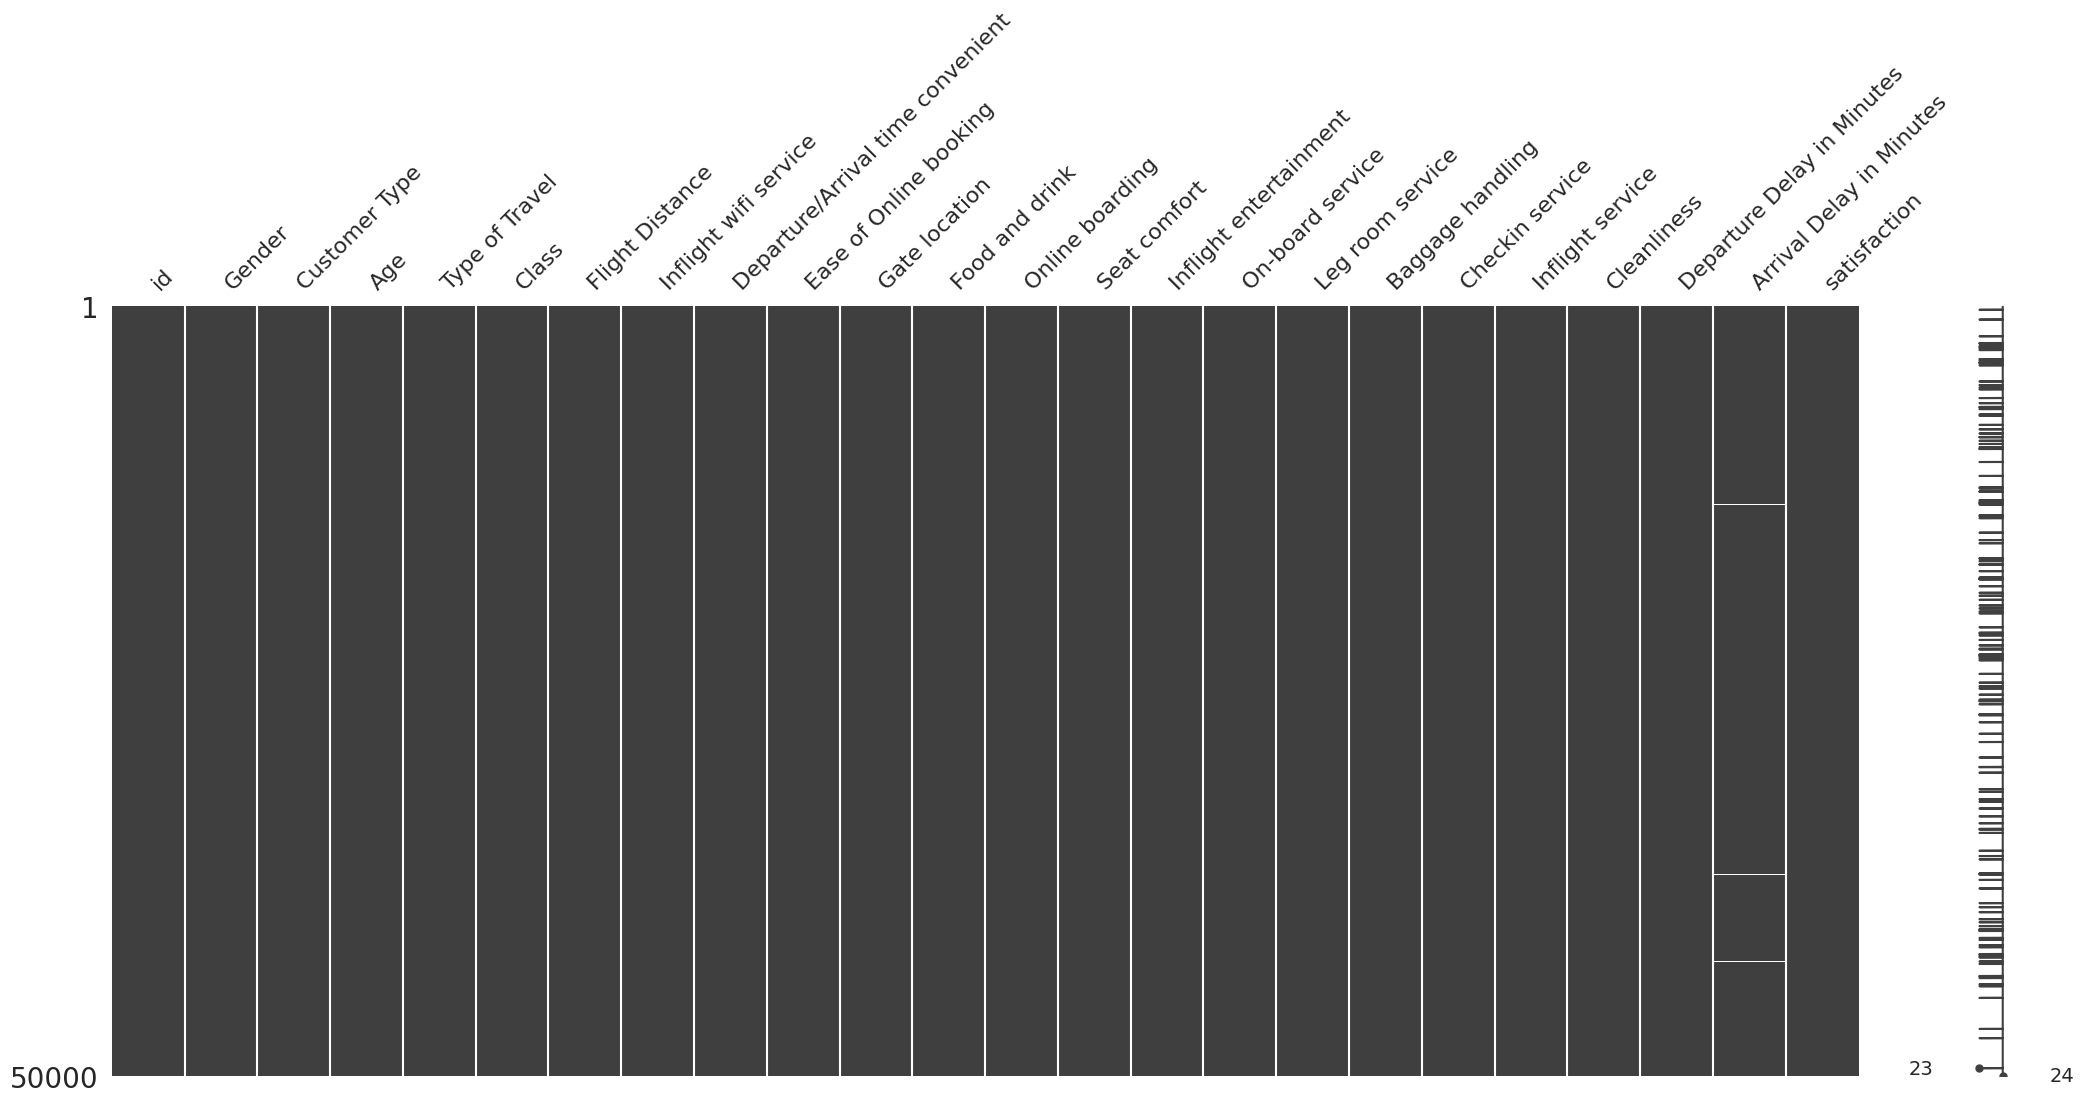

In [10]:
import missingno as msno

msno.matrix(df)
plt.show()

In [11]:
df.nunique()

id                                   50000
Gender                                   2
Customer Type                            2
Age                                     75
Type of Travel                           2
Class                                    3
Flight Distance                       3462
Inflight wifi service                    6
Departure/Arrival time convenient        6
Ease of Online booking                   6
Gate location                            5
Food and drink                           6
Online boarding                          6
Seat comfort                             6
Inflight entertainment                   6
On-board service                         6
Leg room service                         6
Baggage handling                         5
Checkin service                          6
Inflight service                         6
Cleanliness                              6
Departure Delay in Minutes             394
Arrival Delay in Minutes               403
satisfactio

## Check Duplicate Rows

In [12]:
df.duplicated().sum()

np.int64(0)

## Statistical Summary

In [13]:
df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,49842.000000
mean,42942.464440,39.586240,1180.471080,2.723560,3.06092,2.757700,2.979720,3.20054,3.253460,3.439620,3.358380,3.397160,3.36218,3.641940,3.321300,3.659480,3.28500,15.40152,16.173849
std,28035.881699,15.139425,1017.147731,1.328961,1.52619,1.409706,1.282974,1.32933,1.351819,1.320223,1.336076,1.282832,1.31648,1.178915,1.259054,1.171475,1.31437,41.83543,42.403667
min,1.000000,7.000000,56.000000,0.000000,0.00000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.00000,0.00000,0.000000
25%,12500.750000,27.000000,399.000000,2.000000,2.00000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,3.000000,3.000000,2.00000,0.00000,0.000000
50%,50719.500000,40.000000,802.000000,3.000000,3.00000,3.000000,3.000000,3.00000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.00000,0.00000,0.000000
75%,68216.250000,51.000000,1744.000000,4.000000,4.00000,4.000000,4.000000,4.00000,4.000000,5.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.00000,11.00000,13.000000
max,80716.000000,85.000000,4963.000000,5.000000,5.00000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.00000,1592.00000,1584.000000


## Data Dictionary

Identify:

Target → satisfaction
Features → all remaining useful columns
Remove id

## Univariate Analysis
Numerical Columns

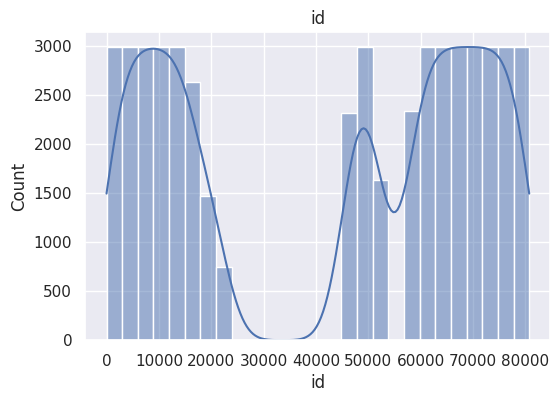

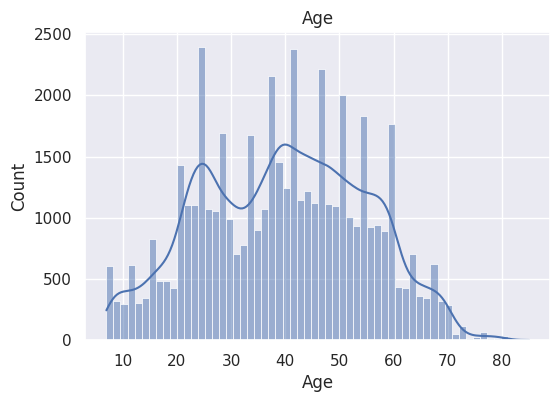

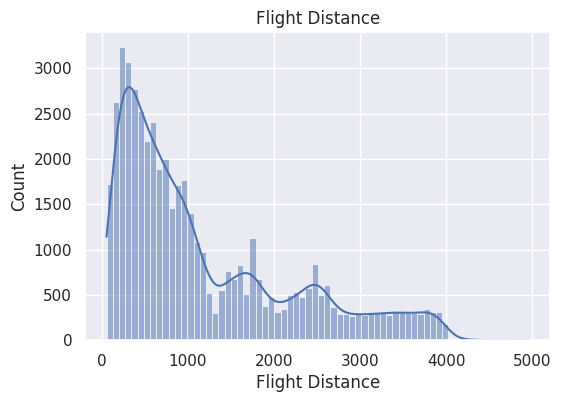

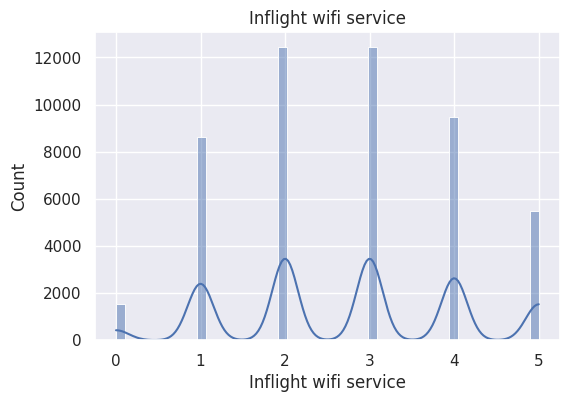

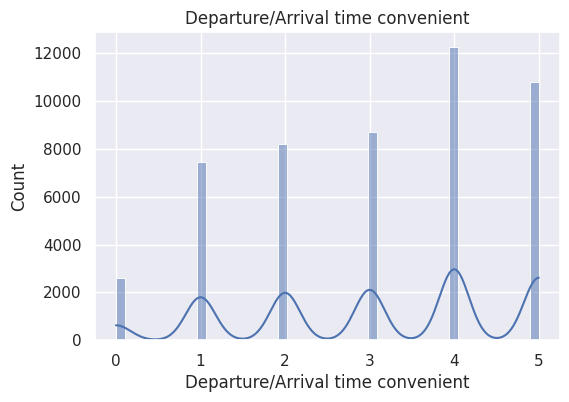

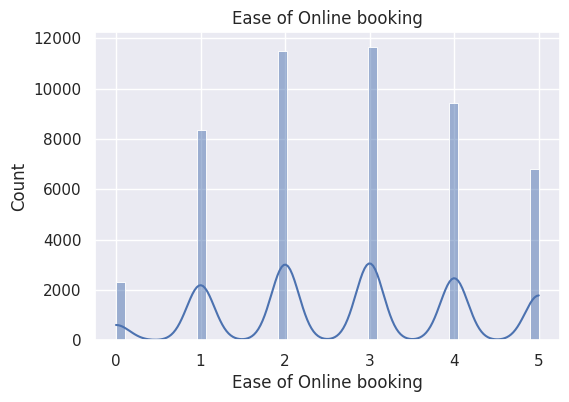

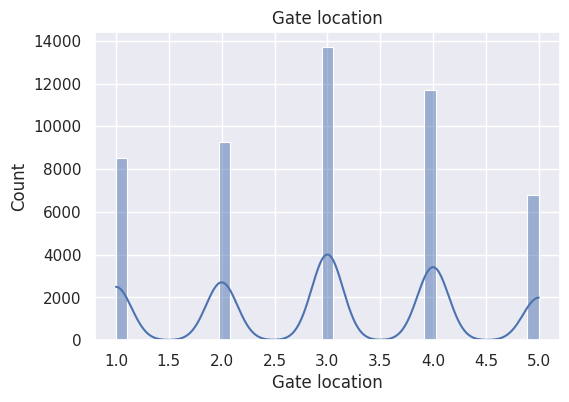

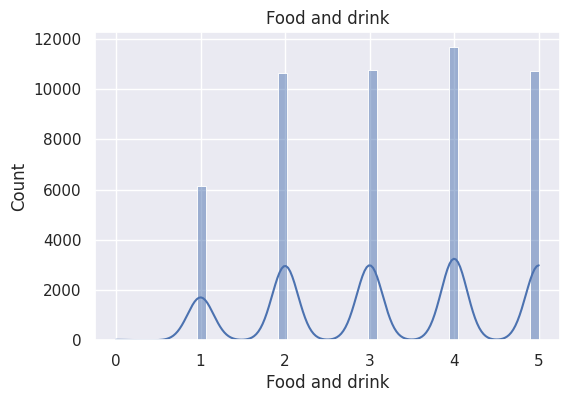

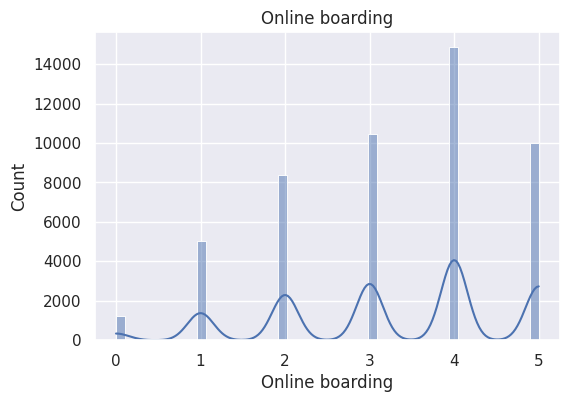

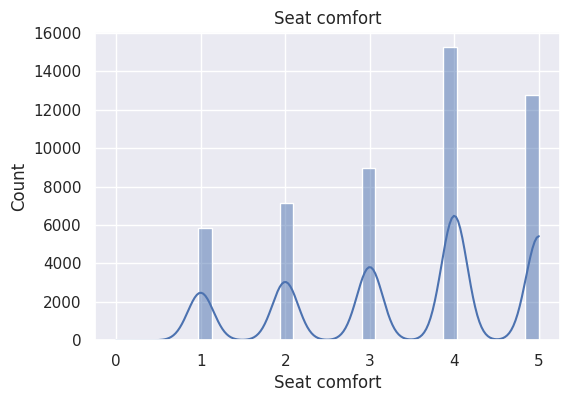

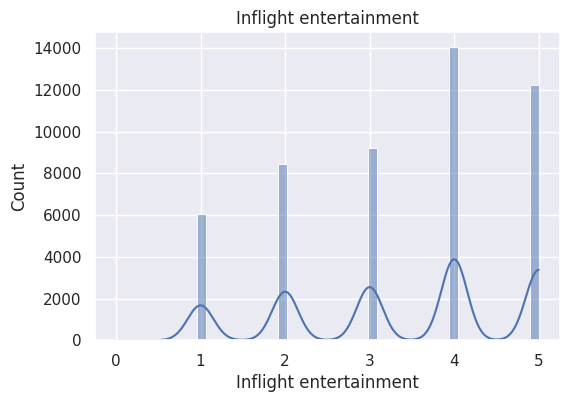

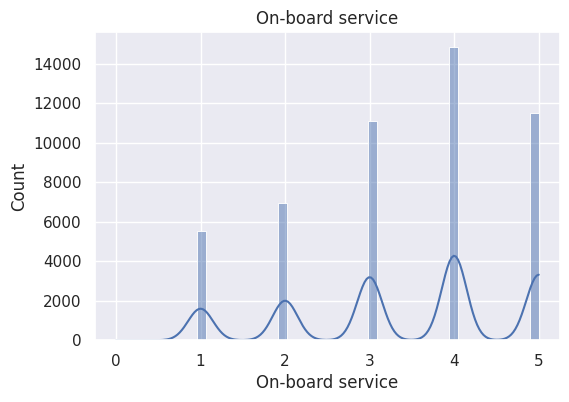

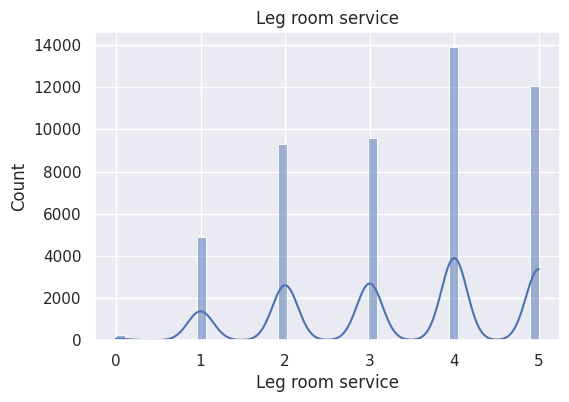

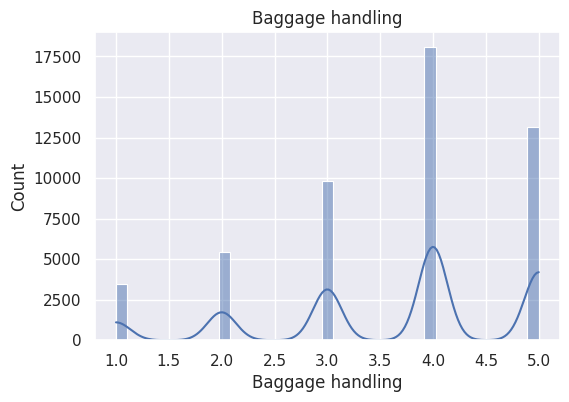

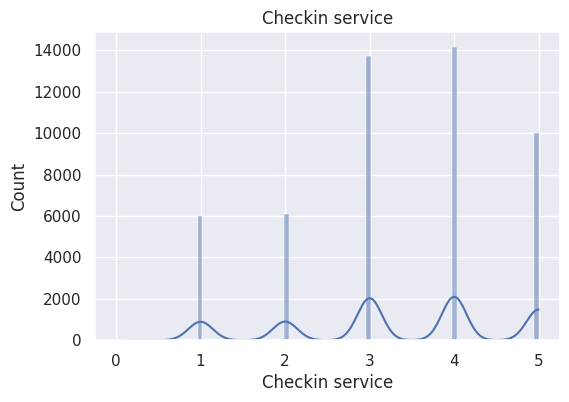

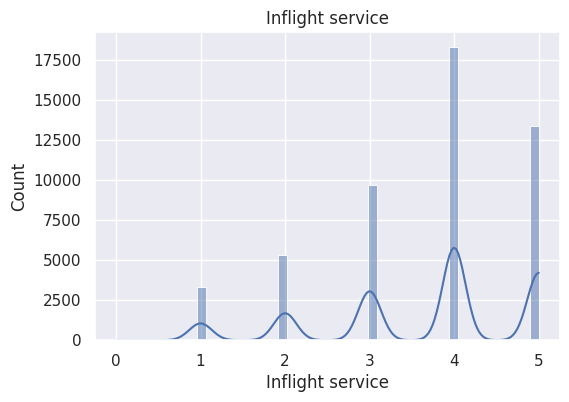

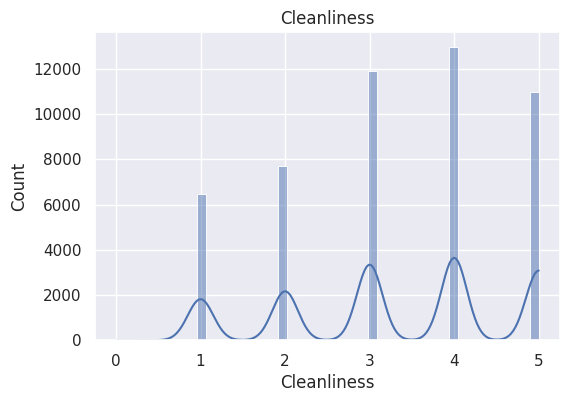

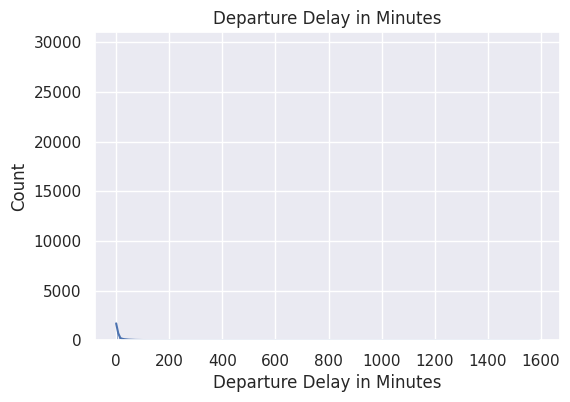

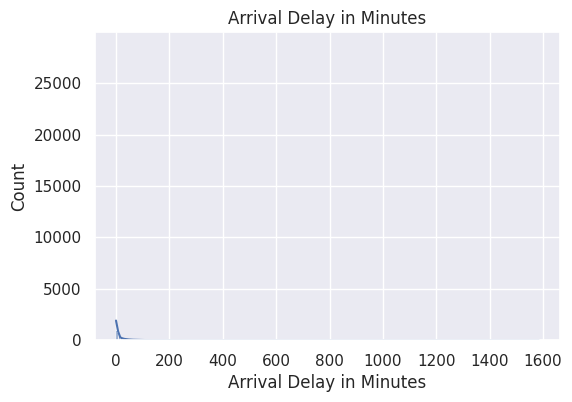

In [14]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

## Categorical Columns

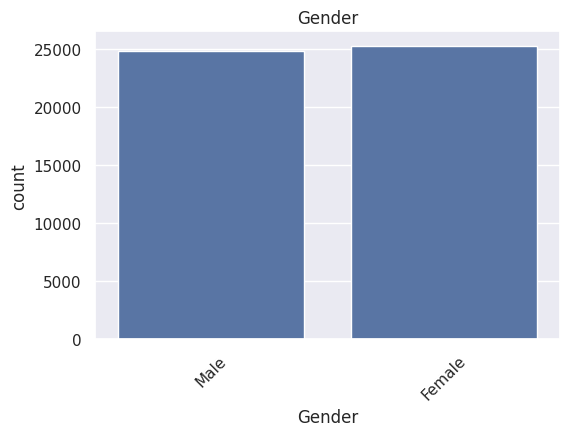

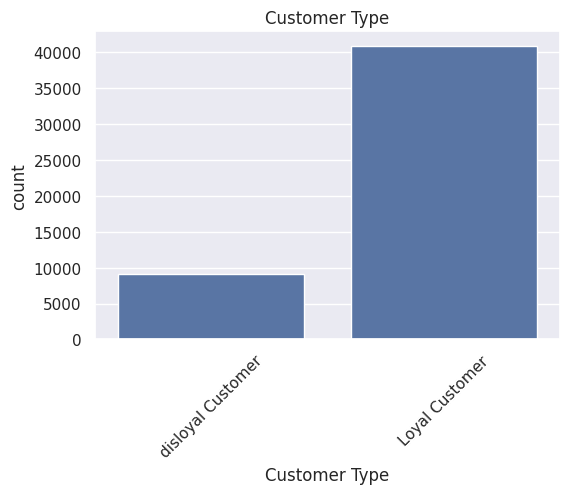

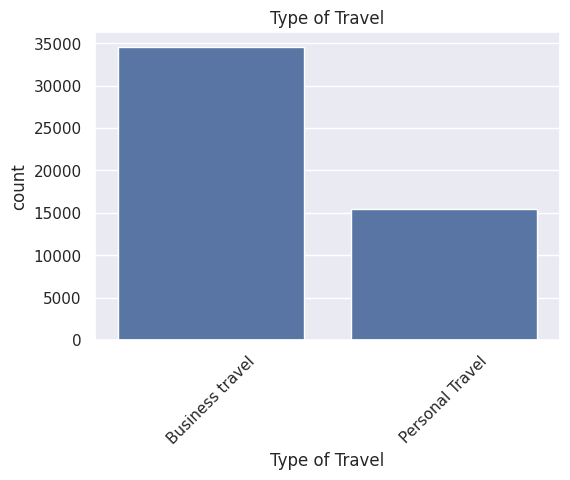

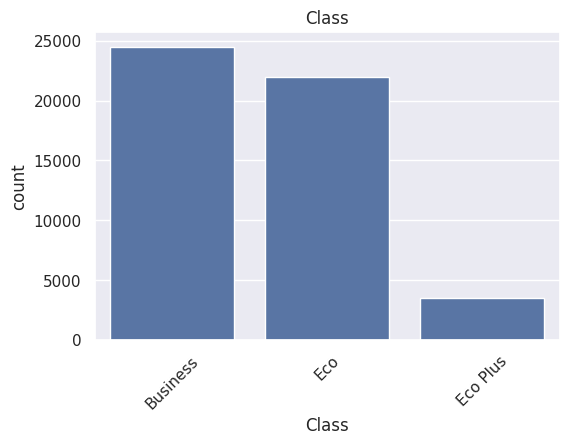

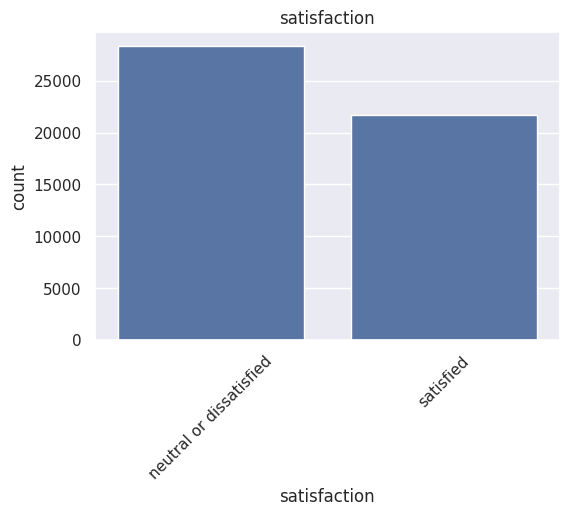

In [15]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df, x=col)

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

## Outlier Detection

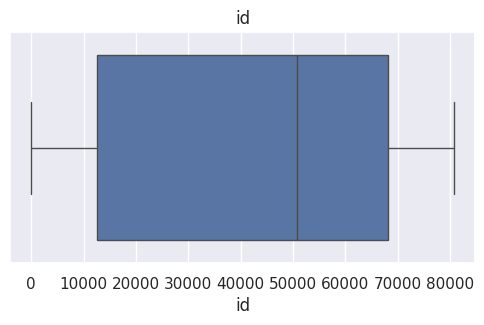

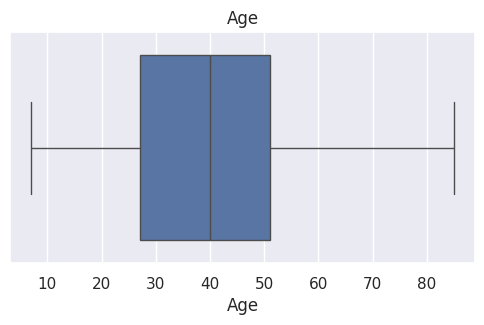

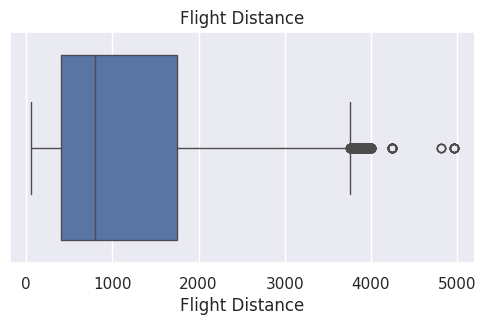

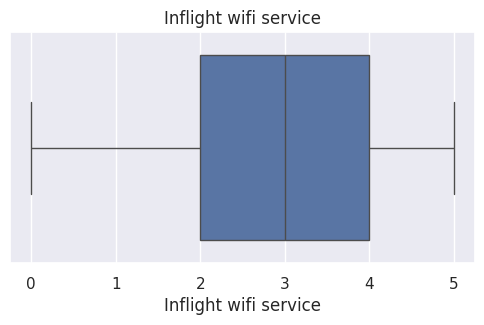

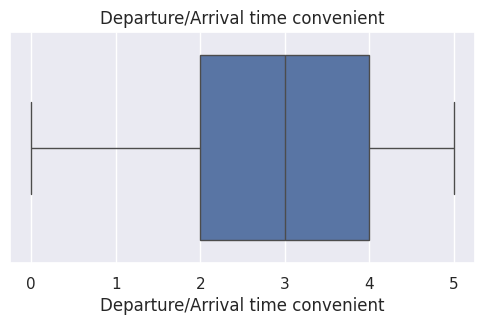

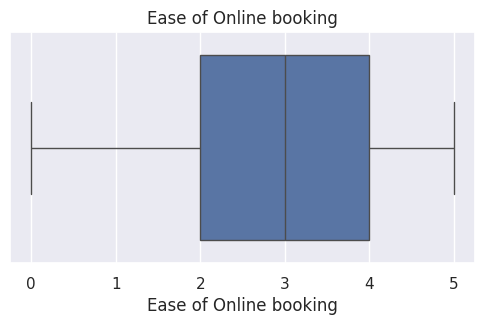

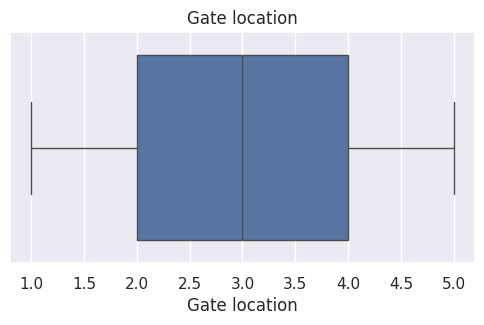

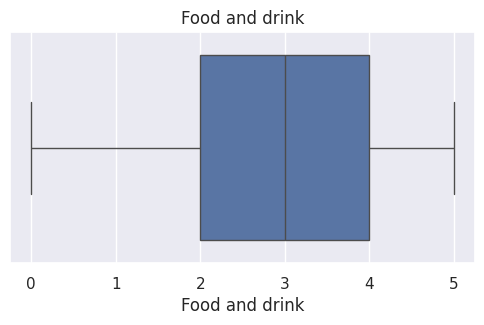

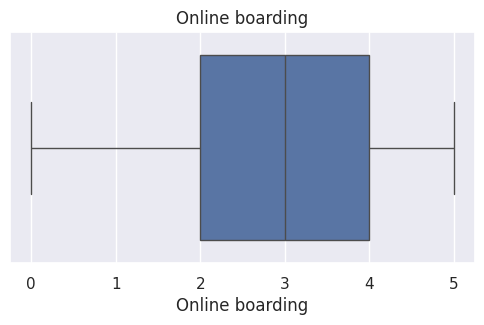

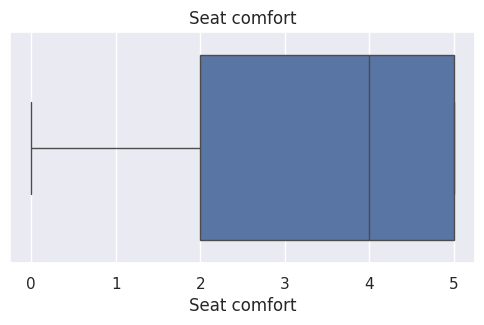

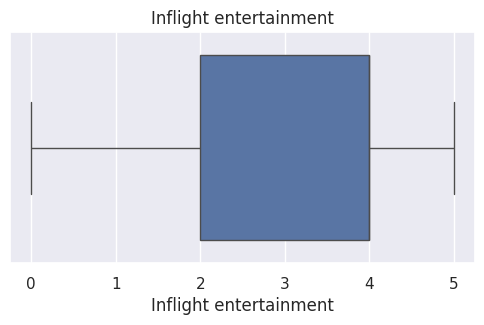

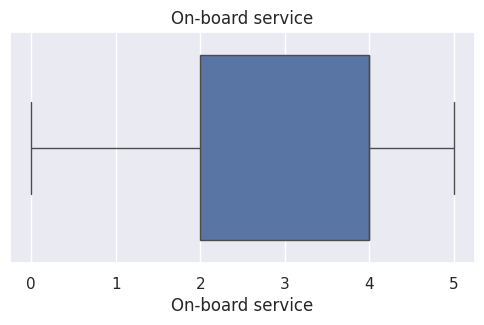

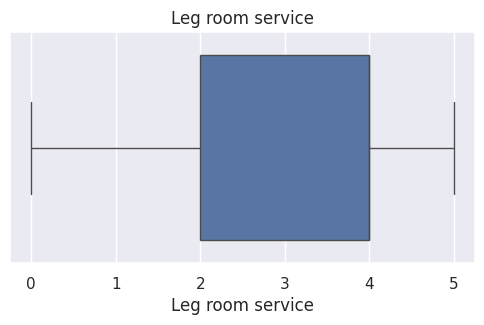

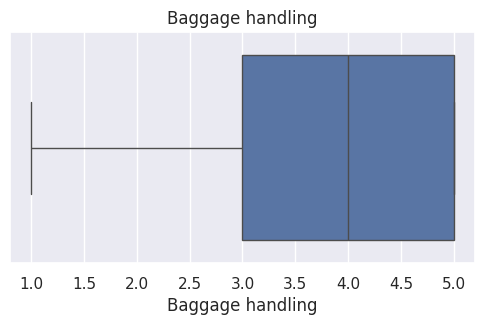

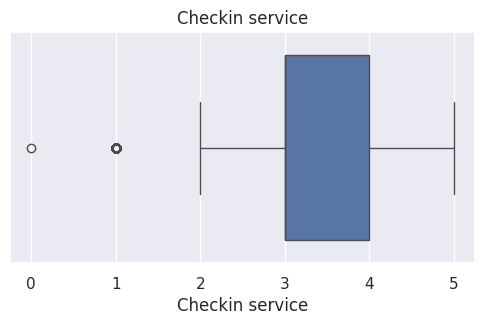

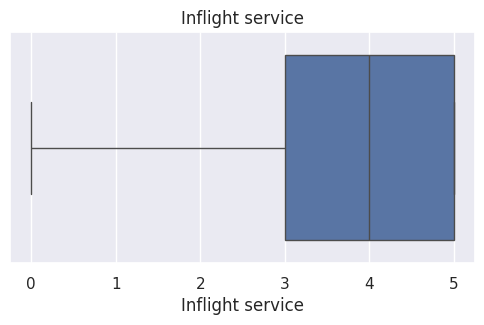

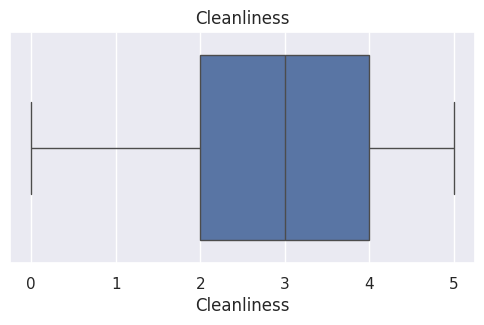

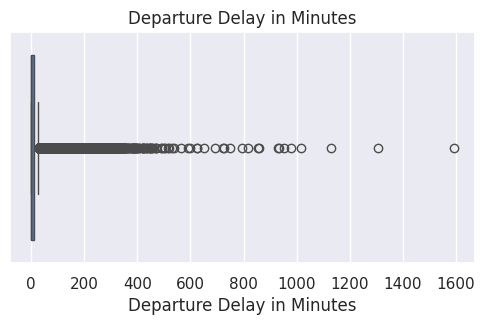

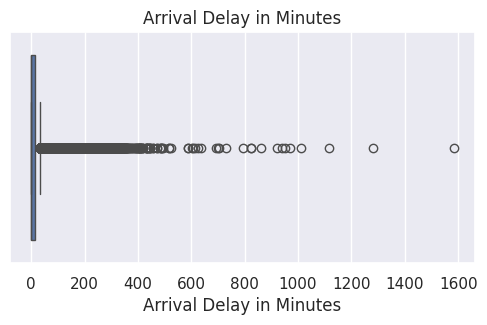

In [16]:
for col in num_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

## Bivariate Analysis
Numerical vs Target

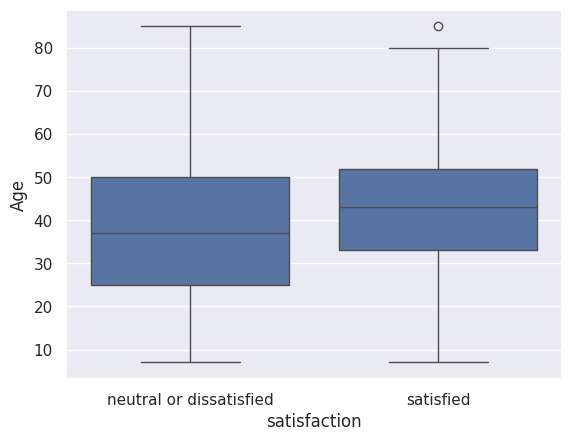

In [17]:
sns.boxplot(x="satisfaction",
            y="Age",
            data=df)

plt.show()

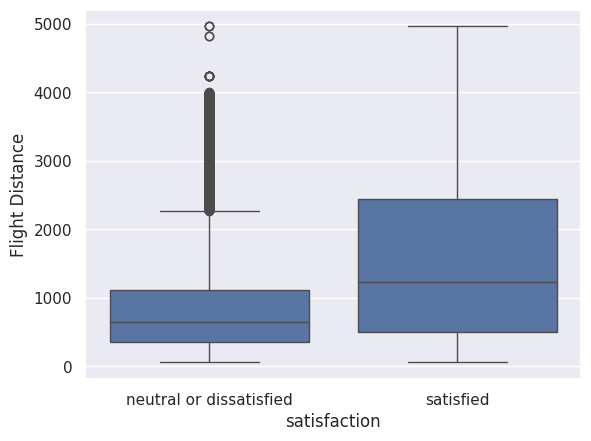

In [18]:
sns.boxplot(x="satisfaction",
            y="Flight Distance",
            data=df)

plt.show()

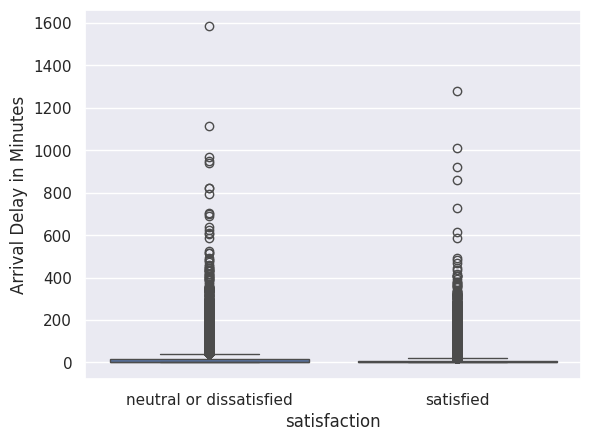

In [19]:
sns.boxplot(x="satisfaction",
            y="Arrival Delay in Minutes",
            data=df)

plt.show()

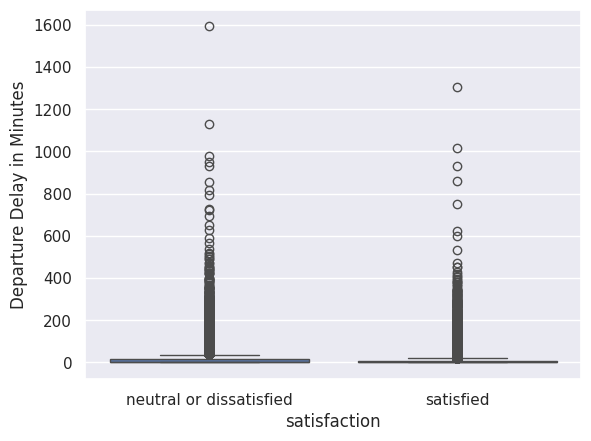

In [20]:
sns.boxplot(x="satisfaction",
            y="Departure Delay in Minutes",
            data=df)

plt.show()

## Categorical vs Target

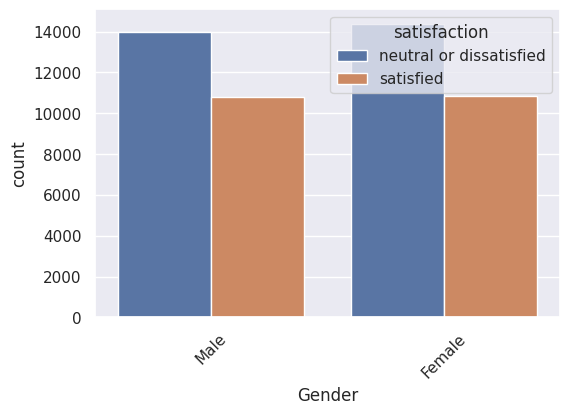

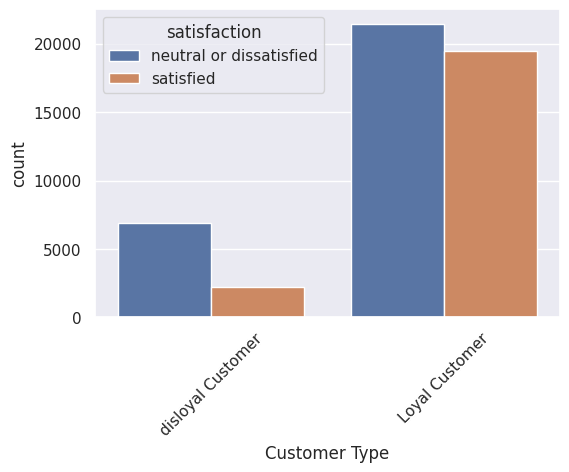

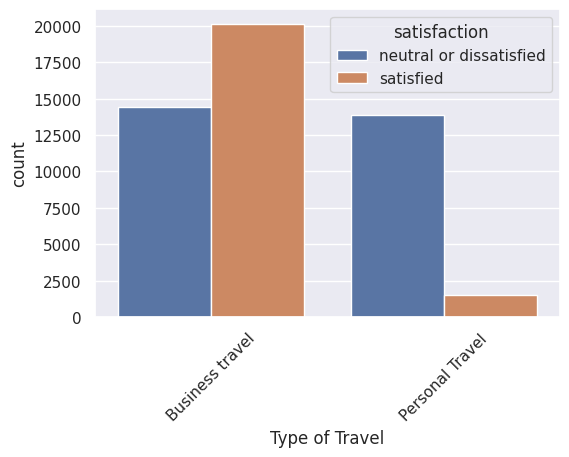

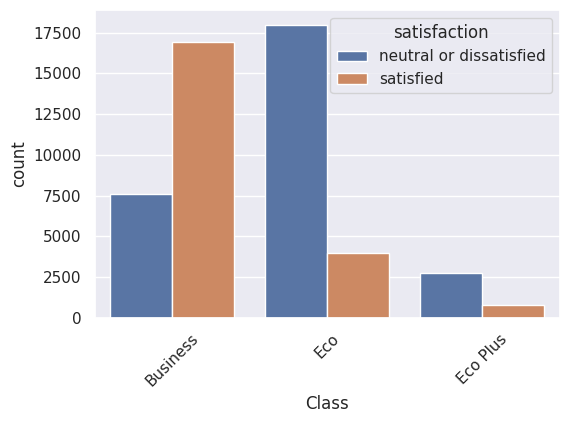

In [21]:
categorical = [

'Gender',
'Customer Type',
'Type of Travel',
'Class'

]

for col in categorical:

    plt.figure(figsize=(6,4))

    sns.countplot(data=df,
                  x=col,
                  hue='satisfaction')

    plt.xticks(rotation=45)

    plt.show()

## Correlation Heatmap

Only numeric columns:

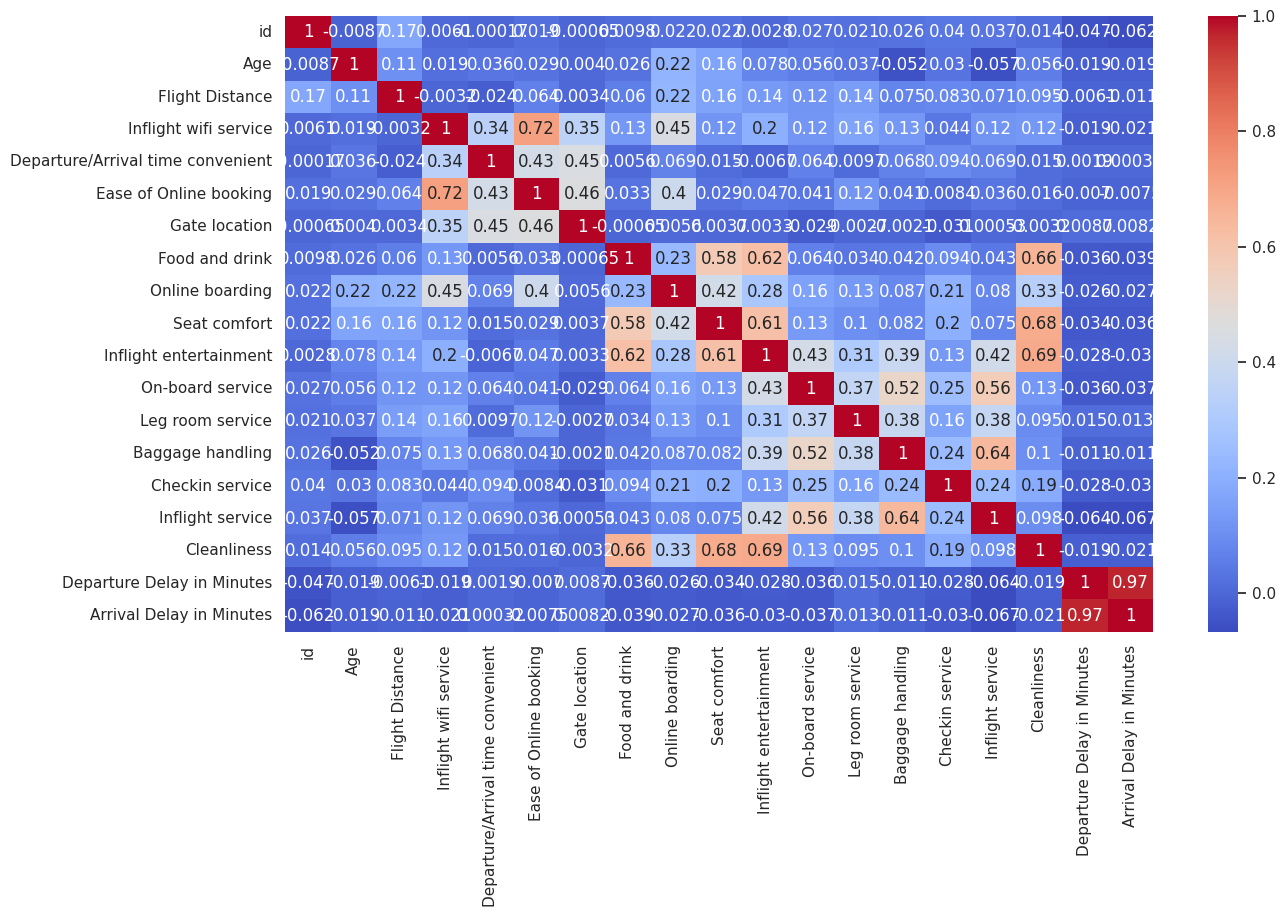

In [22]:
plt.figure(figsize=(14,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

## Feature Engineering

Handle the missing value in:
Arrival Delay in Minutes

In [23]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)

## Encode categorical variables:

In [24]:
import sklearn
encoder = sklearn.preprocessing.LabelEncoder()

for col in df.select_dtypes(include='object').columns:

    df[col] = encoder.fit_transform(df[col])

## Feature Selection

Target:


In [25]:
y = df["satisfaction"]

## Features:

In [26]:
X = df.drop("satisfaction", axis=1)

## Split Dataset

In [27]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.2,

random_state=42
)

## Train a Classification Model

Start with Logistic Regression:

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Prediction

In [29]:
pred = model.predict(X_test)

## Model Evaluation
# ML Model

In [30]:
print("Accuracy")

print(accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

Accuracy
0.8449
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      5670
           1       0.82      0.82      0.82      4330

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



## Confusion Matrix:

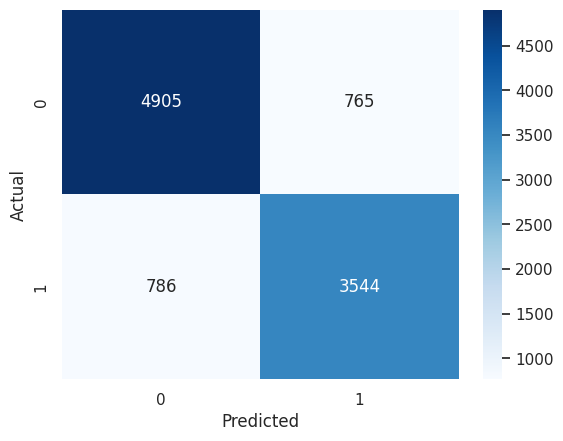

In [31]:
cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Conclusion

Summarize:

Number of records and features.
Missing values handled.
Duplicates cheched.
Important variables affecting passenger satisfaction.
Model used (Logistic Regression).
Accuracy and other evaluation metrics.
Key findings and possible improvements.

# KFold

In [32]:
k_fold = KFold(n_splits= 5, shuffle=True, random_state=42)

## Create all models
## Train and evaluate all models
## Compare all models

Logistic Regression
Accuracy : 0.8449
Precision: 0.8448
Recall   : 0.8449
F1 Score : 0.8449

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.87      0.86      5670
           1       0.82      0.82      0.82      4330

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



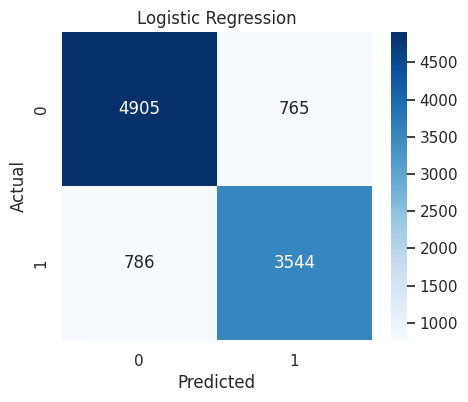

Decision Tree
Accuracy : 0.9468
Precision: 0.9468
Recall   : 0.9468
F1 Score : 0.9468

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5670
           1       0.94      0.94      0.94      4330

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



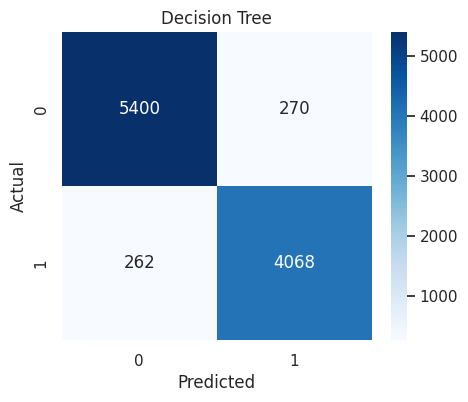

Random Forest
Accuracy : 0.9629
Precision: 0.9632
Recall   : 0.9629
F1 Score : 0.9628

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      5670
           1       0.97      0.94      0.96      4330

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



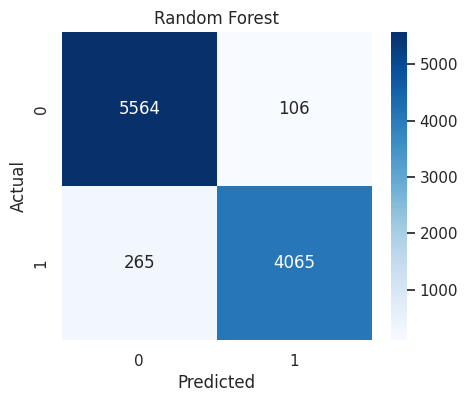

KNN
Accuracy : 0.6863
Precision: 0.6845
Recall   : 0.6863
F1 Score : 0.6849

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.75      0.73      5670
           1       0.65      0.61      0.63      4330

    accuracy                           0.69     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.69      0.68     10000



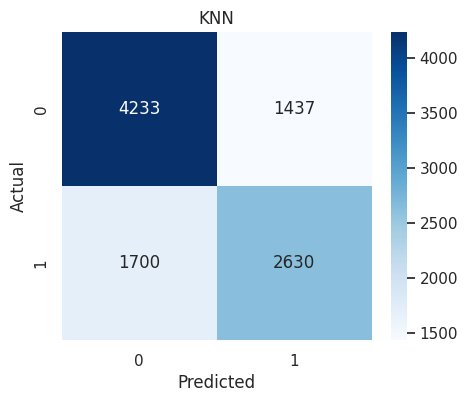

SVM
Accuracy : 0.654
Precision: 0.6657
Recall   : 0.654
F1 Score : 0.6252

Classification Report

              precision    recall  f1-score   support

           0       0.64      0.88      0.74      5670
           1       0.70      0.36      0.47      4330

    accuracy                           0.65     10000
   macro avg       0.67      0.62      0.61     10000
weighted avg       0.67      0.65      0.63     10000



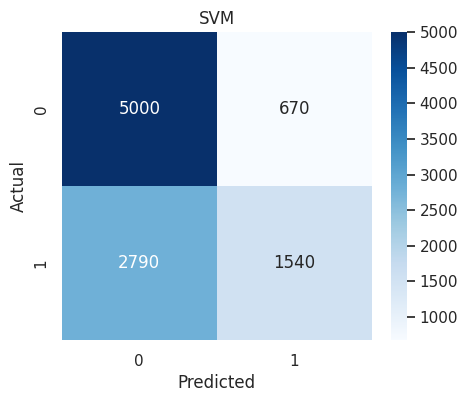

Naive Bayes
Accuracy : 0.8146
Precision: 0.8169
Recall   : 0.8146
F1 Score : 0.8151

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      5670
           1       0.77      0.82      0.79      4330

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.82      0.81      0.82     10000



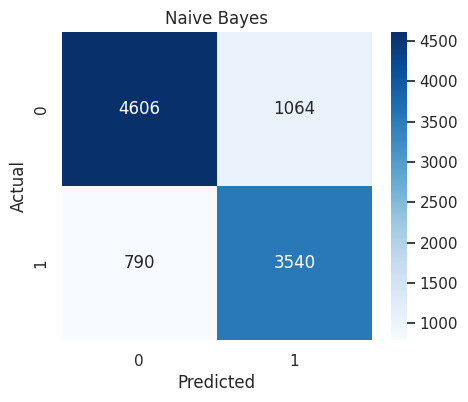

AdaBoost
Accuracy : 0.9165
Precision: 0.9164
Recall   : 0.9165
F1 Score : 0.9164

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      5670
           1       0.91      0.89      0.90      4330

    accuracy                           0.92     10000
   macro avg       0.92      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000



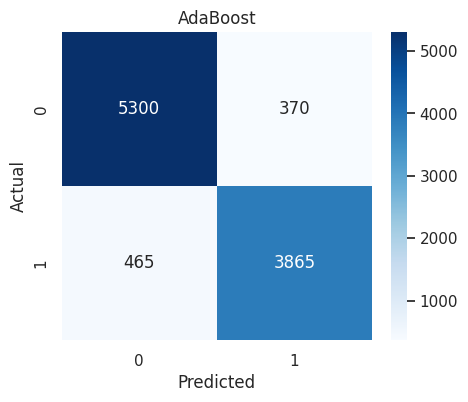

Gradient Boosting
Accuracy : 0.9495
Precision: 0.9497
Recall   : 0.9495
F1 Score : 0.9494

Classification Report

              precision    recall  f1-score   support

           0       0.94      0.97      0.96      5670
           1       0.96      0.92      0.94      4330

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



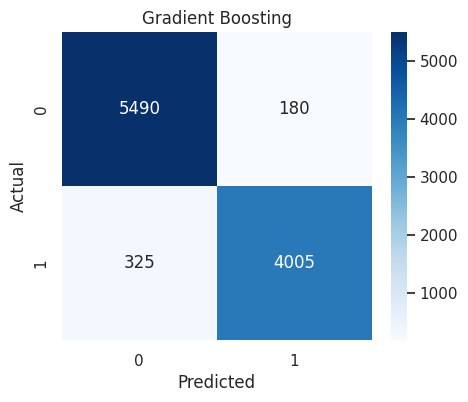

XGBoost
Accuracy : 0.9646
Precision: 0.9647
Recall   : 0.9646
F1 Score : 0.9645

Classification Report

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      5670
           1       0.97      0.95      0.96      4330

    accuracy                           0.96     10000
   macro avg       0.97      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



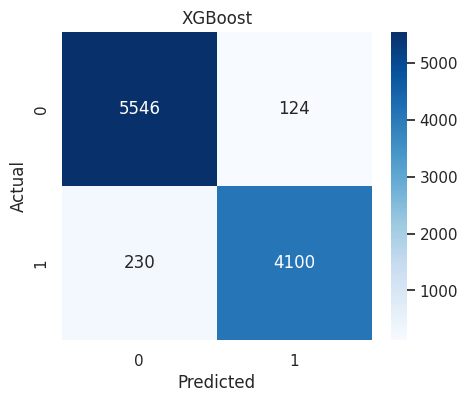

                 Model  Accuracy  Precision  Recall  F1 Score
8              XGBoost    0.9646   0.964711  0.9646  0.964545
2        Random Forest    0.9629   0.963219  0.9629  0.962810
7    Gradient Boosting    0.9495   0.949687  0.9495  0.949389
1        Decision Tree    0.9468   0.946813  0.9468  0.946806
6             AdaBoost    0.9165   0.916436  0.9165  0.916384
0  Logistic Regression    0.8449   0.844817  0.8449  0.844855
5          Naive Bayes    0.8146   0.816921  0.8146  0.815148
3                  KNN    0.6863   0.684543  0.6863  0.684943
4                  SVM    0.6540   0.665657  0.6540  0.625169


In [33]:
# ===========================================
# Import Libraries
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ===========================================
# Models
# ===========================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(),

    "Naive Bayes":
        GaussianNB(),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )
}

# ===========================================
# Train & Evaluate
# ===========================================

results = []

for name, model in models.items():

    print("="*70)
    print(name)
    print("="*70)

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # Save Results
    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1

    })

    # Print Metrics

    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("F1 Score :", round(f1,4))

    print("\nClassification Report\n")

    print(classification_report(y_test,y_pred))

    # Confusion Matrix

    cm = confusion_matrix(y_test,y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

# ===========================================
# Comparison Table
# ===========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

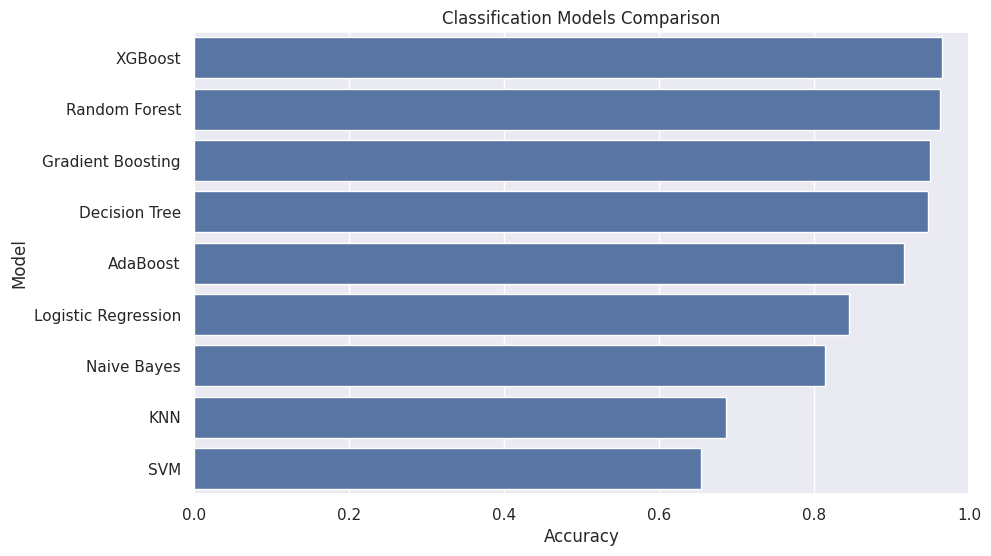

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model"
)

plt.title("Classification Models Comparison")

plt.xlim(0,1)

plt.show()

## Which algorithm is expected to perform best?

For airline customer satisfaction datasets, the performance is often similar to:

Model	Expected Performance
XGBoost	                 ⭐⭐⭐⭐⭐
Gradient Boosting        ⭐⭐⭐⭐⭐
Random Forest	           ⭐⭐⭐⭐
AdaBoost	               ⭐⭐⭐⭐
SVM	                       ⭐⭐⭐⭐
Logistic Regression	         ⭐⭐⭐
Decision Tree	             ⭐⭐⭐
KNN	                           ⭐⭐
Naive Bayes	                   ⭐⭐